# NBA Breakout Analysis
**Author:** Mike Zhang  
**Date:** 2026-03-25  
**Purpose:** Identify players who broke out in the second half of seasons on non-playoff teams and examine whether their post all-star performance from the previous season predicts their following season performance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import os
import statsmodels.api as sm    
import statsmodels.formula.api as smf
from adjustText import adjust_text
from statsmodels.stats.outliers_influence import variance_inflation_factor

os.chdir(r'C:/Users/mikei/OneDrive/Desktop/Python/nba_breakout_analysis')

<Axes: xlabel='PIE_change', ylabel='PIE_diff'>

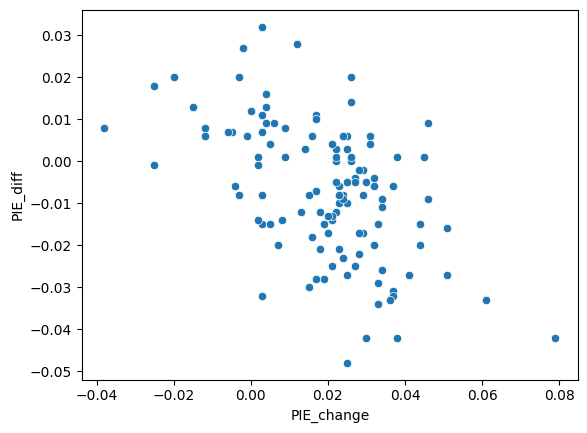

In [2]:
all_candidates = pd.read_csv('data/nba_breakout_candidates.csv')

sns.scatterplot(data = all_candidates, x='PIE_change', y='PIE_diff')

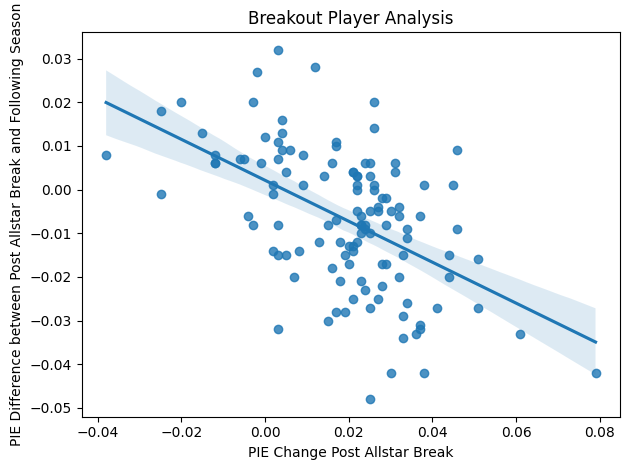

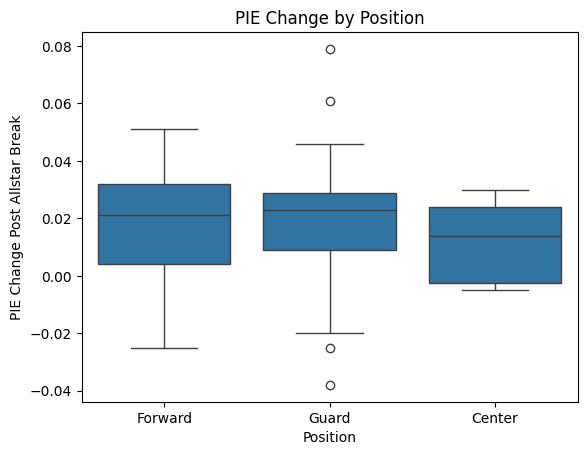

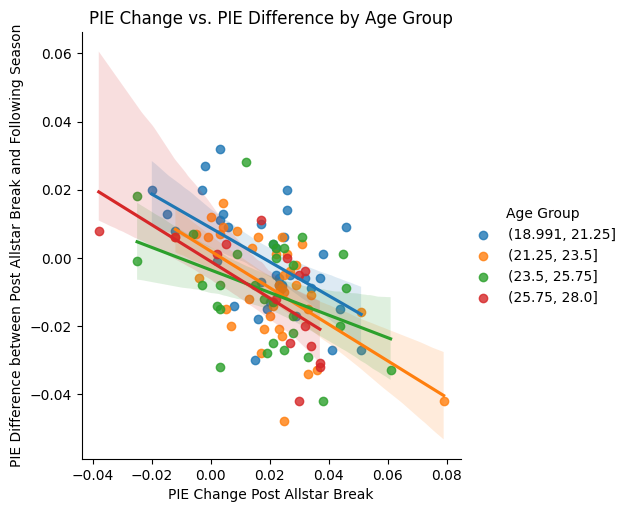

In [3]:
sns.regplot(data=all_candidates, x = 'PIE_change', y = 'PIE_diff')
plt.xlabel('PIE Change Post Allstar Break')
plt.ylabel('PIE Difference between Post Allstar Break and Following Season')
plt.title('Breakout Player Analysis')
plt.tight_layout()
plt.show()

sns.boxplot(data=all_candidates, x='POSITION_simplified', y='PIE_change')
plt.xlabel('Position')
plt.ylabel('PIE Change Post Allstar Break')
plt.title('PIE Change by Position')
plt.savefig('plots/position_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

all_candidates['AGE_bin'] = pd.cut(all_candidates['AGE_post'], bins=4)
sns.lmplot(data=all_candidates, x='PIE_change', y='PIE_diff', hue='AGE_bin').legend.set_title('Age Group')
plt.xlabel('PIE Change Post Allstar Break')
plt.ylabel('PIE Difference between Post Allstar Break and Following Season')
plt.title('PIE Change vs. PIE Difference by Age Group')
plt.savefig('plots/age_binned_regression.png', dpi=150, bbox_inches='tight')
plt.show()

<Axes: xlabel='PIE_diff', ylabel='Count'>

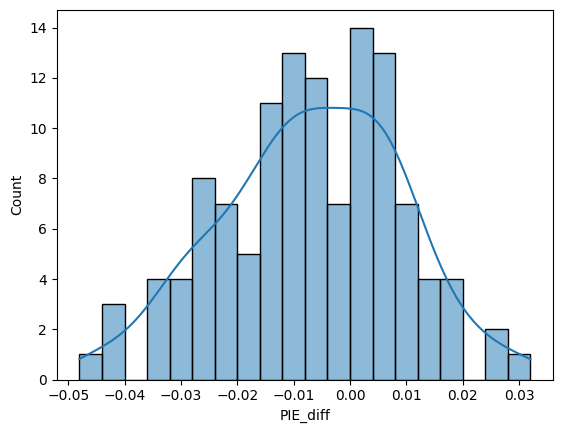

In [4]:
sns.histplot(data=all_candidates, x='PIE_diff', bins=20, kde=True)

In [5]:
def plot_diagnostics(model):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.scatterplot(y=model.resid, x=model.fittedvalues, ax=axes[0])
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_xlabel('Fitted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Fitted Values')
  
    sm.qqplot(model.resid, line='s', ax=axes[1])
    axes[1].set_title('Q-Q Plot')
    
    plt.tight_layout()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               PIE_diff   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     7.093
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.63e-08
Time:                        10:09:31   Log-Likelihood:                 356.58
No. Observations:                 120   AIC:                            -691.2
Df Residuals:                     109   BIC:                            -660.5
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.0474      0.018      2.642      0.009       0.012       0.083
change_team[T.True]                  -0.0065      0.003     -1.955      0.053      -0.013    9.05e-05
C(POSITION_simplified)[T.Forward]     0.0011      0.005      0.215      0.830      -0.009       0.011
C(POSITION_simplified)[T.Guard]       0.0017      0.005      0.349      0.728      -0.008       0.012
PIE_change                           -0.4895      0.074     -6.597      0.000      -0.637      -0.342
OVERALL_PICK                         -0.0001   7.61e-05     -1.443      0.152      -0.000     4.1e-05
PIE_pre                              -0.1224      0.068     -1.788      0.077      -0.258       0.013
USG_change                           -0.0427      0.054     -0.790      0.431      -0.150       0.064
AGE_post                             -0.0011      0.001     -1.709      0.090      -0.002       0.000
MIN_post                             -0.0003      0.000     -0.592      0.555      -0.001       0.001
avg_wins_3yr                       3.706e-05      0.000      0.217      0.829      -0.000       0.000
==============================================================================
Omnibus:                        0.549   Durbin-Watson:                   1.969
Prob(Omnibus):                  0.760   Jarque-Bera (JB):                0.670
Skew:                           0.026   Prob(JB):                        0.715
Kurtosis:                       2.638   Cond. No.                     3.73e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.73e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

,Variable,VIF
0,PIE_change,2.573920
1,PIE_pre,17.851649
2,USG_change,1.990716
3,OVERALL_PICK,3.340840
4,AGE_post,79.601238
5,MIN_post,70.598481
6,avg_wins_3yr,25.128433


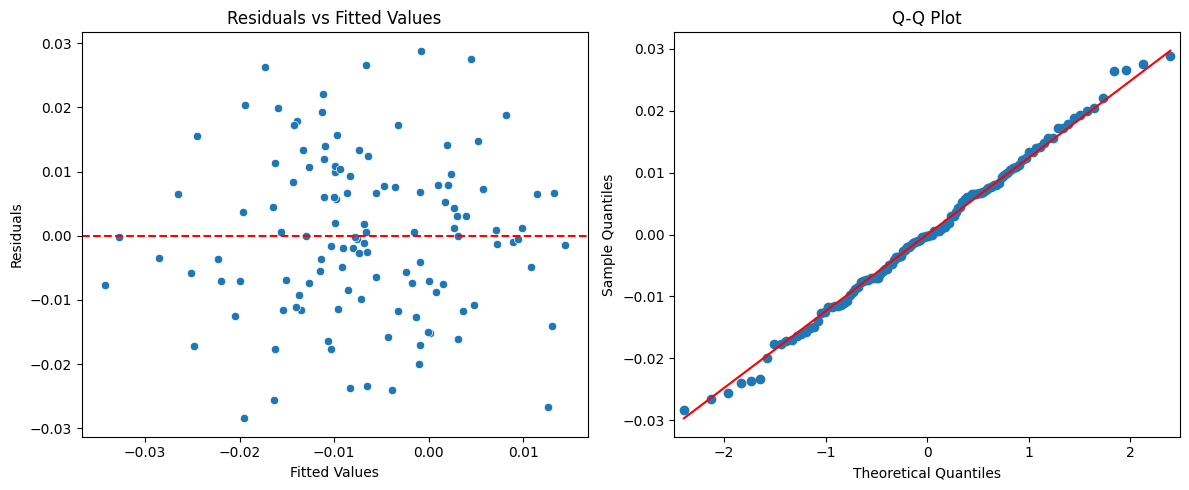

In [6]:
diff_model = smf.ols('PIE_diff ~ PIE_change + change_team + OVERALL_PICK + PIE_pre + USG_change + AGE_post + MIN_post + avg_wins_3yr + C(POSITION_simplified)', data=all_candidates).fit()
display(diff_model.summary())

# Diagnostic plots
plot_diagnostics(diff_model)

# Calculate VIF for multicollinearity
numerical_predictors = all_candidates[['PIE_change', 'PIE_pre', 'USG_change', 'OVERALL_PICK', 'AGE_post', 'MIN_post', 'avg_wins_3yr']]
vif = [variance_inflation_factor(numerical_predictors.values, i) for i in range(numerical_predictors.shape[1])]
vif_df = pd.DataFrame({'Variable': numerical_predictors.columns, 'VIF': vif})
vif_df

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               PIE_diff   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.337
Method:                 Least Squares   F-statistic:                     11.08
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.09e-09
Time:                        10:09:32   Log-Likelihood:                 354.27
No. Observations:                 120   AIC:                            -694.5
Df Residuals:                     113   BIC:                            -675.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.0339      0.014      2.423      0.017       0.006       0.062
change_team[T.True]                  -0.0054      0.003     -1.680      0.096      -0.012       0.001
C(POSITION_simplified)[T.Forward]     0.0047      0.005      1.019      0.310      -0.004       0.014
C(POSITION_simplified)[T.Guard]       0.0047      0.004      1.088      0.279      -0.004       0.013
PIE_change                           -0.5106      0.070     -7.274      0.000      -0.650      -0.372
OVERALL_PICK                      -9.971e-05    7.4e-05     -1.348      0.180      -0.000    4.69e-05
AGE_post                             -0.0014      0.001     -2.216      0.029      -0.003      -0.000
==============================================================================
Omnibus:                        0.039   Durbin-Watson:                   1.971
Prob(Omnibus):                  0.981   Jarque-Bera (JB):                0.025
Skew:                          -0.023   Prob(JB):                        0.988
Kurtosis:                       2.945   Cond. No.                     2.10e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.1e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

,Variable,VIF
0,PIE_change,2.223372
1,AGE_post,4.810525
2,OVERALL_PICK,3.055383


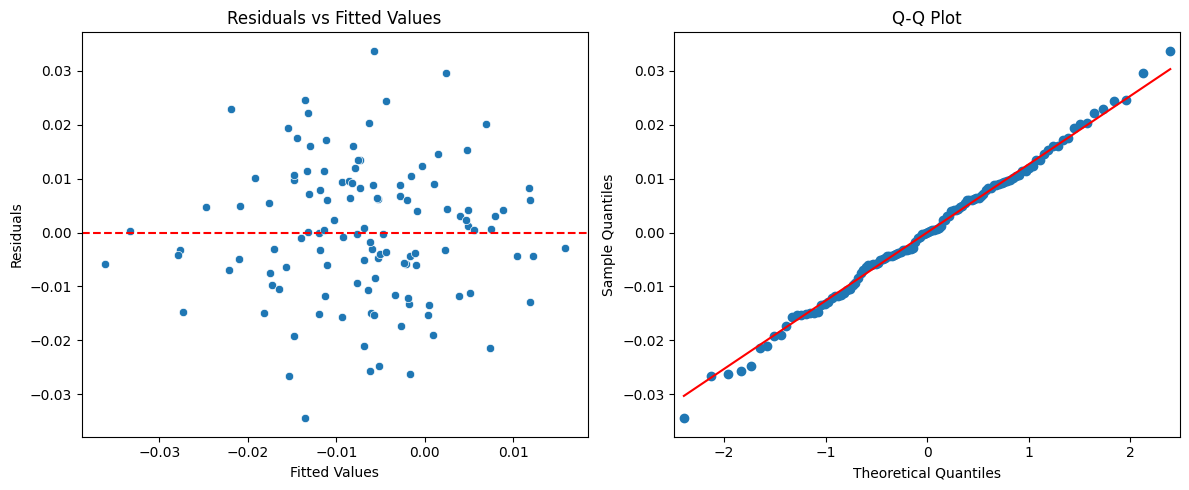

In [7]:
# Refine doff_model to address multicollinearity
diff_model = smf.ols('PIE_diff ~ PIE_change + OVERALL_PICK + AGE_post + change_team + C(POSITION_simplified)', data=all_candidates).fit()
display(diff_model.summary())

plot_diagnostics(diff_model)

numerical_predictors_reduced = all_candidates[['PIE_change', 'AGE_post', 'OVERALL_PICK']]
vif_reduced = [variance_inflation_factor(numerical_predictors_reduced.values, i) for i in range(numerical_predictors_reduced.shape[1])]
vif_reduced_df = pd.DataFrame({'Variable': numerical_predictors_reduced.columns, 'VIF': vif_reduced})
vif_reduced_df

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               PIE_diff   R-squared:                       0.347
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     15.28
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           4.75e-10
Time:                        10:09:32   Log-Likelihood:                 352.08
No. Observations:                 120   AIC:                            -694.2
Df Residuals:                     115   BIC:                            -680.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=====================================================================================================
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.0450      0.013      3.460      0.001       0.019       0.071
C(POSITION_simplified)[T.Forward]     0.0037      0.005      0.800      0.425      -0.005       0.013
C(POSITION_simplified)[T.Guard]       0.0030      0.004      0.698      0.486      -0.006       0.012
PIE_change                           -0.4739      0.068     -6.934      0.000      -0.609      -0.339
AGE_post                             -0.0020      0.001     -3.587      0.000      -0.003      -0.001
==============================================================================
Omnibus:                        0.153   Durbin-Watson:                   1.933
Prob(Omnibus):                  0.926   Jarque-Bera (JB):                0.127
Skew:                          -0.075   Prob(JB):                        0.939
Kurtosis:                       2.946   Cond. No.                     1.31e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.31e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

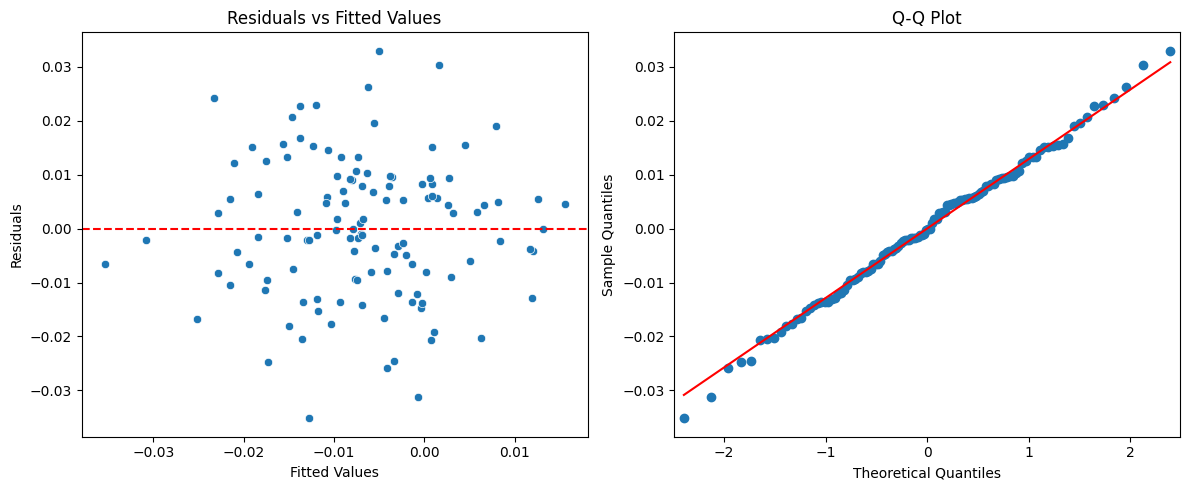

In [8]:
# Refine model again 
diff_model = smf.ols('PIE_diff ~ PIE_change + AGE_post + C(POSITION_simplified)', data=all_candidates).fit()
display(diff_model.summary())

plot_diagnostics(diff_model)
plt.savefig('plots/diff_model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


8 influential points identified


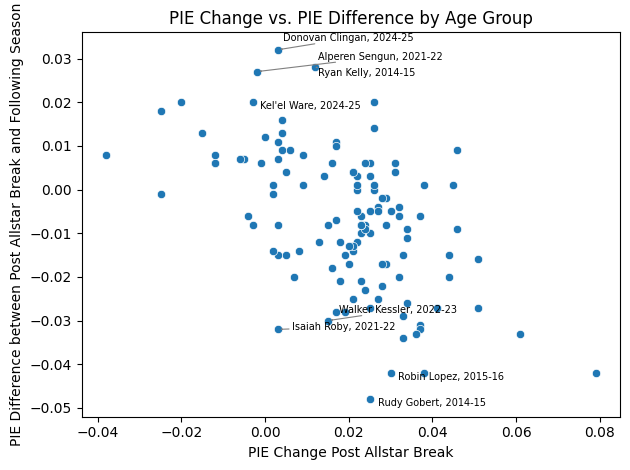

In [9]:
influence = diff_model.get_influence()
cooks = influence.cooks_distance[0]
all_candidates['cooks_d'] = cooks

threshold = 4 / len(all_candidates)
outliers = all_candidates[all_candidates['cooks_d'] > threshold]
print(f"{len(outliers)} influential points identified")

ax = sns.scatterplot(data=all_candidates, x='PIE_change', y='PIE_diff')

texts = []
for _, row in outliers.iterrows():
    texts.append(ax.text(
        row['PIE_change'], row['PIE_diff'],
        f"{row['PLAYER_NAME_post']}, {row['season']}",
        fontsize=7
    ))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))
plt.xlabel('PIE Change Post Allstar Break')
plt.ylabel('PIE Difference between Post Allstar Break and Following Season')
plt.title('PIE Change vs. PIE Difference by Age Group')
plt.tight_layout()
plt.savefig('plots/outlier_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


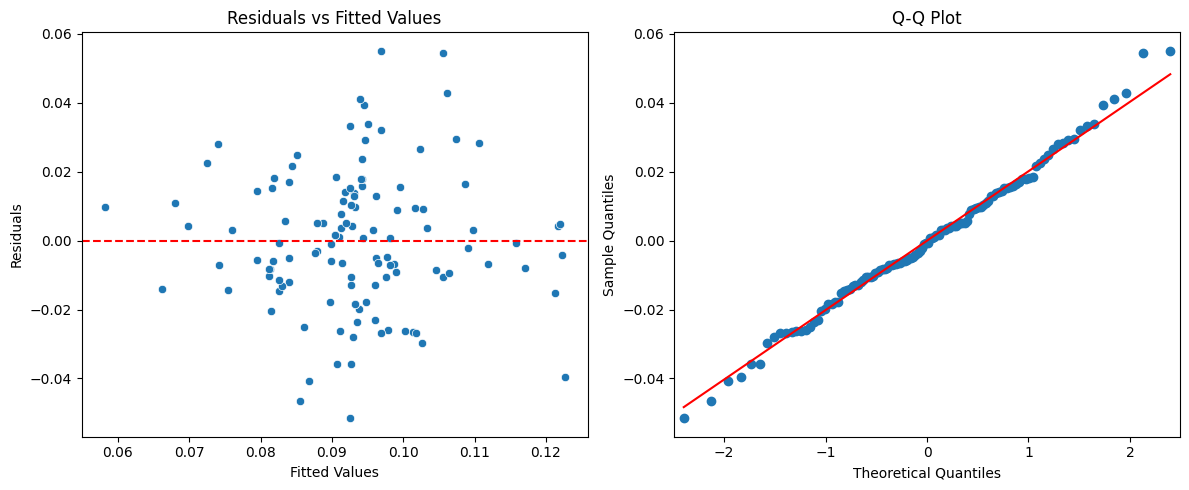

In [10]:
# Fit a secondary model 
following_model = smf.ols('PIE_following ~ PIE_change + AGE_post + C(POSITION_simplified)', data=all_candidates).fit()
following_model.summary()
 
plot_diagnostics(following_model)
plt.savefig('plots/following_model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# Logisti Regression to predict breakout status
all_candidates['sustained'] = (all_candidates['PIE_diff'] >= 0).astype(int)
all_candidates['sustained'].value_counts()

all_candidates['PIE_change_scaled'] = all_candidates['PIE_change'] * 100

logit_model = smf.logit(
    'sustained ~ PIE_change_scaled + AGE_post + C(POSITION_simplified)',
    data=all_candidates
).fit()
display(logit_model.summary())

odds_ratios = np.exp(logit_model.params)
conf = np.exp(logit_model.conf_int().rename(columns={0: '2.5%', 1: '97.5%'}))
conf['OR'] = odds_ratios
print(conf)

Optimization terminated successfully.
         Current function value: 0.573502
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              sustained   No. Observations:                  120
Model:                          Logit   Df Residuals:                      115
Method:                           MLE   Df Model:                            4
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                  0.1434
Time:                        10:09:35   Log-Likelihood:                -68.820
converged:                       True   LL-Null:                       -80.339
Covariance Type:            nonrobust   LLR p-value:                 0.0001245
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             2.8866      2.292      1.259      0.208      -1.607       7.380
C(POSITION_simplified)[T.Forward]     0.3645      0.775      0.470      0.638      -1.154       1.883
C(POSITION_simplified)[T.Guard]       0.2419      0.728      0.332      0.740      -1.185       1.668
PIE_change_scaled                    -0.5807      0.144     -4.029      0.000      -0.863      -0.298
AGE_post                             -0.1120      0.100     -1.122      0.262      -0.307       0.084
=====================================================================================================
"""

                                       2.5%        97.5%         OR
Intercept                          0.200587  1602.995866  17.931529
C(POSITION_simplified)[T.Forward]  0.315320     6.574274   1.439792
C(POSITION_simplified)[T.Guard]    0.305885     5.303036   1.273624
PIE_change_scaled                  0.421809     0.742112   0.559490
AGE_post                           0.735325     1.087120   0.894084


In [12]:
# Save models using pickle

with open('models/diff_model.pkl', 'wb') as f:
    pickle.dump(diff_model, f)

with open('models/following_model.pkl', 'wb') as f:
    pickle.dump(following_model, f)

with open('models/logit_model.pkl', 'wb') as f:
    pickle.dump(logit_model, f)